In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "../data/processed/life_expectancy_features.csv"

df = pd.read_csv(file_path)

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (16866, 62)


Basic statistics

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,16866.0,1.992038e+03,1.875768e+01,1.960000e+03,1.976000e+03,1.992000e+03,2.008000e+03,2.024000e+03
Life_Expectancy,16866.0,6.493979e+01,1.108503e+01,1.098900e+01,5.801973e+01,6.736742e+01,7.306133e+01,8.649700e+01
Infant_Mortality,16866.0,5.016872e+01,4.314732e+01,1.200000e+00,1.660000e+01,3.880000e+01,7.100000e+01,4.840000e+02
Under5_Mortality,16866.0,7.323566e+01,7.394754e+01,1.300000e+00,1.950000e+01,4.877990e+01,1.010123e+02,7.809000e+02
Neonatal_Mortality,16866.0,2.405761e+01,1.750605e+01,5.000000e-01,1.050000e+01,2.100000e+01,3.300000e+01,1.042000e+02
Maternal_Mortality,16866.0,2.825854e+02,4.260272e+02,1.000000e+00,3.500000e+01,1.040000e+02,3.707500e+02,8.045000e+03
Death_Rate,16866.0,1.034152e+01,5.455651e+00,8.410000e-01,6.930500e+00,9.092500e+00,1.216350e+01,1.539630e+02
Fertility_Rate,16866.0,3.814826e+00,1.958337e+00,5.820000e-01,2.040000e+00,3.296000e+00,5.639750e+00,8.864000e+00
Birth_Rate,16866.0,2.768555e+01,1.299543e+01,3.519000e+00,1.593900e+01,2.630000e+01,3.930775e+01,5.761300e+01
Adolescent_Fertility,16866.0,7.155136e+01,5.019478e+01,4.650000e-01,2.973400e+01,6.046600e+01,1.067255e+02,2.296040e+02


Life Expectancy distribution

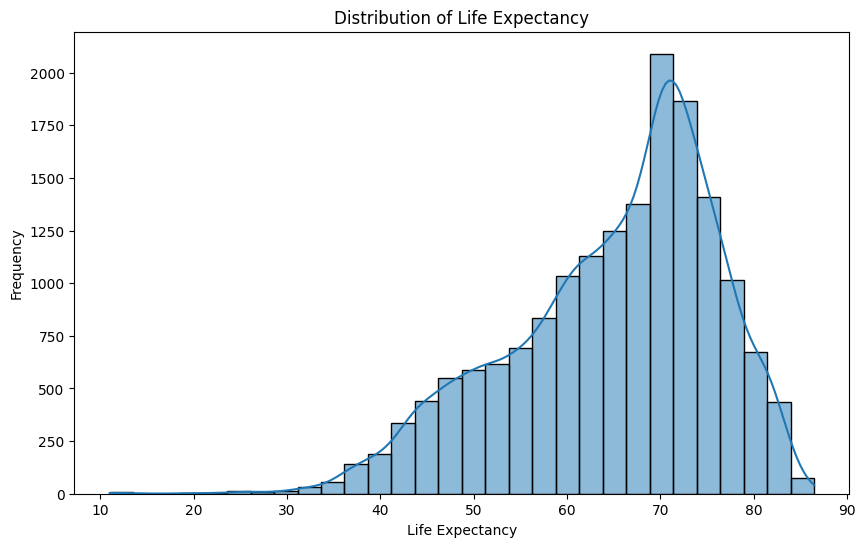

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Life_Expectancy"],
    bins=30,
    kde=True
)

plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

Life Expectancy over time

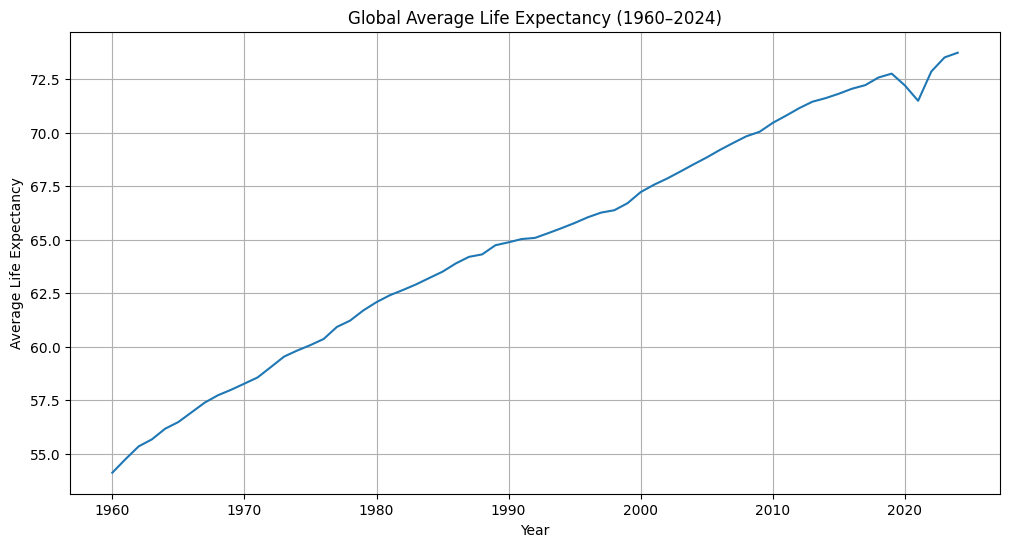

In [5]:
yearly_life = df.groupby(
    "Year"
)["Life_Expectancy"].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_life.index,
    yearly_life.values
)

plt.title("Global Average Life Expectancy (1960–2024)")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.grid(True)

plt.show()

Top 10 countries

In [6]:
latest_year = df["Year"].max()

latest = df[
    df["Year"] == latest_year
].sort_values(
    "Life_Expectancy",
    ascending=False
)

latest[
    ["Country", "Life_Expectancy"]
].head(10)

,Country,Life_Expectancy
10460,Monaco,86.497000
13060,San Marino,85.817000
6629,"Hong Kong SAR, China",85.392683
8250,Kuwait,84.580488
15010,Switzerland,84.407317
9095,Liechtenstein,84.200000
5459,French Polynesia,84.192000
454,Andorra,84.188000
14945,Sweden,84.063415
7730,Japan,84.036341


Bottom 10 countries

In [7]:
latest[
    ["Country", "Life_Expectancy"]
].tail(10)

,Country,Life_Expectancy
1559,Benin,60.961000
6239,Guinea,60.904000
9680,Mali,60.675000
194,Africa Western and Central,59.041538
13905,"Somalia, Fed. Rep.",58.967000
8900,Lesotho,57.798000
14165,South Sudan,57.738000
2729,Central African Republic,57.671000
2859,Chad,55.238000
11370,Nigeria,54.635000


Life expectancy by decade

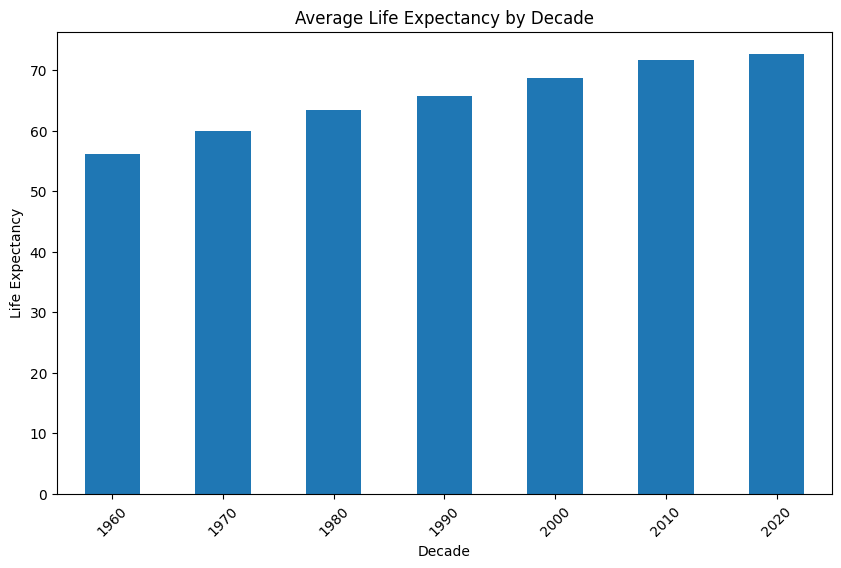

In [8]:
decade_life = df.groupby(
    "Decade"
)["Life_Expectancy"].mean()

plt.figure(figsize=(10, 6))

decade_life.plot(
    kind="bar"
)

plt.title("Average Life Expectancy by Decade")
plt.xlabel("Decade")
plt.ylabel("Life Expectancy")
plt.xticks(rotation=45)

plt.show()

Correlation with target

In [9]:
correlations = df.select_dtypes(
    include=np.number
).corr()["Life_Expectancy"].sort_values(
    ascending=False
)

correlations

Life_Expectancy                   1.000000
Infrastructure_Index              0.810200
Health_Service_Access             0.806183
Education_Index                   0.804309
Secondary_Enrollment              0.790646
Basic_Sanitation_Access           0.782896
Electricity_Access                0.778441
Basic_Water_Access                0.764365
Population_WorkingAge             0.752525
DPT_Immunization                  0.729267
Clean_Cooking_Access              0.711370
Urban_Population                  0.711359
Population_Elderly                0.649750
Measles_Immunization              0.648700
Tertiary_Enrollment               0.641085
Physicians                        0.619254
Economic_Health_Index             0.523922
Primary_Enrollment                0.522032
GDP_Per_Capita                    0.500643
Internet_Users                    0.496282
Years_Since_1960                  0.495894
Year                              0.495894
GNI_Per_Capita                    0.495432
Mobile_Subs

Top positive correlations

In [10]:
correlations.head(11)

Life_Expectancy            1.000000
Infrastructure_Index       0.810200
Health_Service_Access      0.806183
Education_Index            0.804309
Secondary_Enrollment       0.790646
Basic_Sanitation_Access    0.782896
Electricity_Access         0.778441
Basic_Water_Access         0.764365
Population_WorkingAge      0.752525
DPT_Immunization           0.729267
Clean_Cooking_Access       0.711370
Name: Life_Expectancy, dtype: float64

Strongest negative correlations

In [11]:
correlations.tail(10)

Maternal_Mortality       -0.771034
Death_Rate               -0.781201
Adolescent_Fertility     -0.790814
Population_Young         -0.795135
Fertility_Rate           -0.861825
Neonatal_Mortality       -0.863745
Birth_Rate               -0.884894
Infant_Mortality         -0.903151
Under5_Mortality         -0.905056
Child_Mortality_Burden   -0.909991
Name: Life_Expectancy, dtype: float64

Correlation heatmap

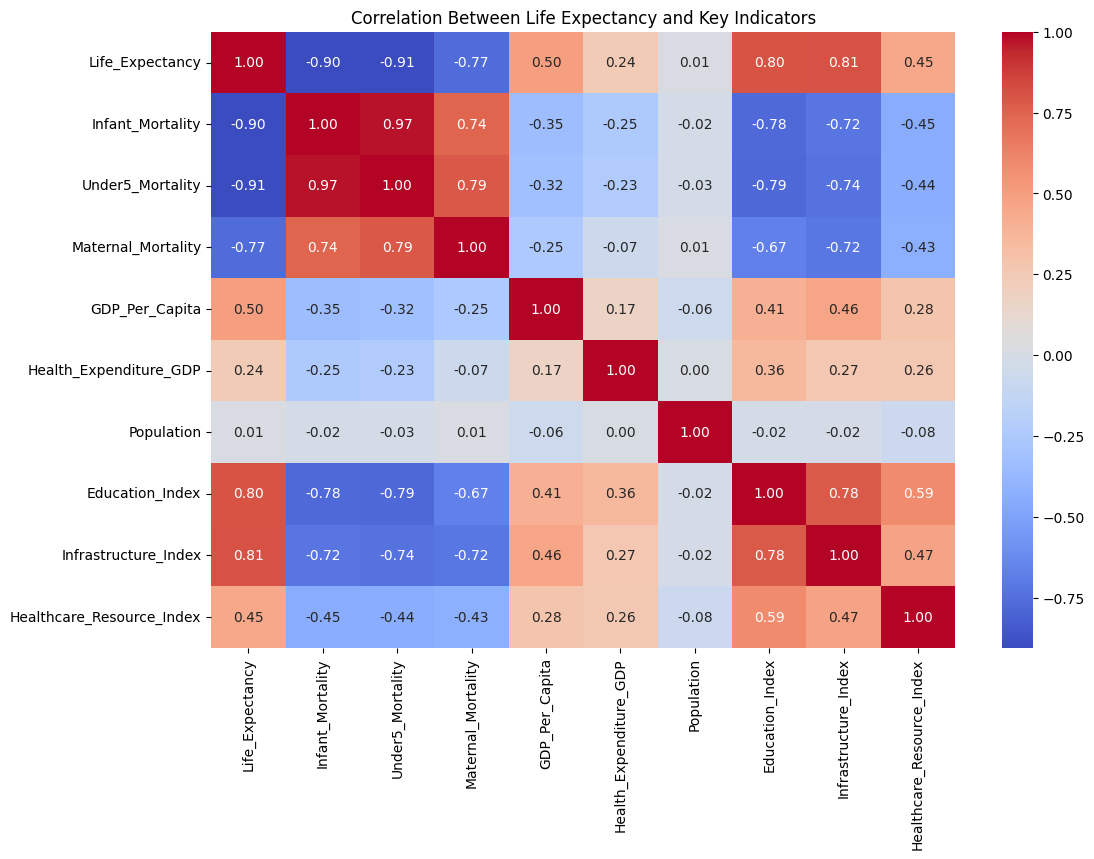

In [12]:
important_features = [
    "Life_Expectancy",
    "Infant_Mortality",
    "Under5_Mortality",
    "Maternal_Mortality",
    "GDP_Per_Capita",
    "Health_Expenditure_GDP",
    "Population",
    "Education_Index",
    "Infrastructure_Index",
    "Healthcare_Resource_Index"
]

corr_matrix = df[
    important_features
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Life Expectancy and Key Indicators")

plt.show()